# CPA + Profiling DL SCA for SASCA (Multi-Target)

A multi-target attack, analysing the three intermediate targets theta output, rho_pi output and chi output.
Only one lane is targeted for every target: 
- theta[0,0]
- rho_pi[0,0]
- chi[3,0]

For every one of the intermediate values: 
- A correlation power analysis is performed using the HW leakage model to estimate the correlation and to calculate the 50 best POIs, used to train the DL model.
- A CNN is trained with hyperparameter tuning using the *profiling traces* subset producing probabilities for SASCA.
- The final profiling attack is performed on the *attack traces* subset.

In [16]:
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

## Keccak-f[1600] Round 1 Emulation

Round 1 returns the 3 intermediate targets:

- theta output
- rho_pi output
- chi output

In [17]:
def bit_rotate_left(val, shift):
    return ((val << shift) & 0xFFFFFFFFFFFFFFFF) | (val >> (64 - shift))

def compute_round1_chi_full(msg_array):
    N = len(msg_array)
    S = np.zeros((5, 5, N), dtype=np.uint64)
    S[0, 0] = msg_array.astype(np.uint64)
    
    # 1. THETA
    C = np.zeros((5, N), dtype=np.uint64)
    for x in range(5):
        C[x] = S[x,0] ^ S[x,1] ^ S[x,2] ^ S[x,3] ^ S[x,4]
        
    D = np.zeros((5, N), dtype=np.uint64)
    for x in range(5):
        D[x] = C[(x-1)%5] ^ bit_rotate_left(C[(x+1)%5], 1)
        
    theta_out = np.zeros((5, 5, N), dtype=np.uint64)
    for x in range(5):
        for y in range(5):
            theta_out[x, y] = S[x, y] ^ D[x]
            
    # 2. RHO e PI
    rho_pi = np.zeros((5, 5, N), dtype=np.uint64)
    offsets = {
        (0,0): (0,0,0),  (0,2): (1,0,1),  (0,4): (2,0,62), (0,1): (3,0,28), (0,3): (4,0,27),
        (1,3): (0,1,36), (1,0): (1,1,44), (1,2): (2,1,6),  (1,4): (3,1,55), (1,1): (4,1,20),
        (2,1): (0,2,3),  (2,3): (1,2,10), (2,0): (2,2,43), (2,2): (3,2,25), (2,4): (4,2,39),
        (3,4): (0,3,41), (3,1): (1,3,45), (3,3): (2,3,15), (3,0): (3,3,21), (3,2): (4,3,8),
        (4,2): (0,4,18), (4,4): (1,4,2),  (4,1): (2,4,61), (4,3): (3,4,56), (4,0): (4,4,14)
    }
    for (x_out, y_out), (x_in, y_in, shift) in offsets.items():
        rho_pi[x_out, y_out] = bit_rotate_left(theta_out[x_in, y_in], shift)
        
    # 3. CHI (S-box)
    chi_out = np.zeros((5, 5, N), dtype=np.uint64)
    for x in range(5):
        for y in range(5):
            chi_out[x, y] = rho_pi[x, y] ^ ((~rho_pi[(x+1)%5, y]) & rho_pi[(x+2)%5, y])
            
    return theta_out, rho_pi, chi_out, S

Dataset and Preprocessing

For the theta and rho_pi intermediate values, the first lane is selected as target because it is the only one containing the message in the first round, all the other lanes are all zero-values.

In [18]:
with h5py.File("../Dataset/keccak_unprotected.h5", "r") as f:
    traces = np.array(f["random/traces"], dtype=np.float32)
    inputs = np.array(f["random/inputs"], dtype=np.uint8)

# Split Profiling (to train the model) e Attack subsets
attack_traces = traces[9900:]
attack_inputs = inputs[9900:]
traces = traces[:9900]
inputs = inputs[:9900]

# 64-bit message reconstruction
msg = np.zeros(len(inputs), dtype=np.uint64)
for i in range(8):
    msg |= inputs[:, i].astype(np.uint64) << (i * 8)

attack_msg = np.zeros(len(attack_inputs), dtype=np.uint64)
for i in range(8):
    attack_msg |= attack_inputs[:, i].astype(np.uint64) << (i * 8)

# Intermediate states extraction
theta_tr, rho_pi_tr, chi_tr, state_init_tr = compute_round1_chi_full(msg)
theta_at, rho_pi_at, chi_at, _ = compute_round1_chi_full(attack_msg)

# targets dictionary with all the target lanes
targets = {
    "theta_out":  {"train": theta_tr[0,0],  "attack": theta_at[0,0]},
    "rho_pi_out": {"train": rho_pi_tr[0,0], "attack": rho_pi_at[0,0]},
    "chi_out":    {"train": chi_tr[3,0],    "attack": chi_at[3,0]}
}

## CPA

Best POis seletion and correlation.

In [19]:
def compute_hw_leakage(state_target):
    N = state_target.shape[2]
    hw_leakage = np.zeros(N, dtype=np.float32)
    
    for x in range(5):
        for y in range(5):
            val = state_target[x, y]
            hw_leakage += np.array([bin(int(v)).count("1") for v in val], dtype=np.float32)
            
    return hw_leakage


def select_pois(traces, leakage, num_pois=50):
    corrs = []
    stds = np.std(traces, axis=0)
    for t in range(traces.shape[1]):
        if stds[t] < 1e-6:
            corrs.append(0.0)
        else:
            corr = np.corrcoef(traces[:, t], leakage)[0, 1]
            corrs.append(corr)
    corrs = np.array(corrs)
    top_k_POI = np.argsort(np.abs(corrs))[-num_pois:]
    return top_k_POI, corrs


## DL Model 

CNN model trained with hyperparameter tuning

In [20]:
def tune_cnn_architecture(X_tr, y_tr, X_val, y_val):
    best_acc = 0
    best_config = {}
    
    param_grid = {
        'num_blocks': [1, 2],       # num of (consecutive) blocks Conv+BN+Pool
        'init_filters': [16, 32],   # filters in first layer
        'dense_units': [64, 128],   # neurons in fully-connected layer
        'lr': [1e-3, 5e-4],         # learning-rate
        'dropout': [0.3, 0.4]       # dropout rate
    }
    
    for blocks in param_grid['num_blocks']:
        for filters in param_grid['init_filters']:
            for units in param_grid['dense_units']:
                for lr in param_grid['lr']:
                    for d_rate in param_grid['dropout']:
                        
                        model = tf.keras.Sequential()
                        model.add(tf.keras.layers.Input(shape=(X_tr.shape[1], 1)))
                        
                        curr_filters = filters
                        for b in range(blocks):
                            model.add(tf.keras.layers.Conv1D(filters=curr_filters, kernel_size=3, activation='relu', padding='same'))
                            model.add(tf.keras.layers.BatchNormalization())
                            model.add(tf.keras.layers.AveragePooling1D(pool_size=2 if X_tr.shape[1] >= 4 else 1))
                            curr_filters *= 2
                        
                        model.add(tf.keras.layers.Flatten())
                        model.add(tf.keras.layers.Dense(units, activation='relu'))
                        model.add(tf.keras.layers.Dropout(d_rate))
                        model.add(tf.keras.layers.Dense(64, activation='sigmoid')) # 64 independent outputs (multi-label)
                        
                        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                                      loss='binary_crossentropy', metrics=['binary_accuracy'])
                        
                        history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=5, batch_size=64, verbose=0)
                        val_acc = max(history.history['val_binary_accuracy'])
                        
                        if val_acc > best_acc:
                            best_acc = val_acc
                            best_config = {
                                'num_blocks': blocks, 'init_filters': filters, 
                                'dense_units': units, 'lr': lr, 'dropout': d_rate
                            }
    return best_config

def build_and_train_best_model(X_train, y_train, config):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1], 1)))
    
    curr_filters = config['init_filters']
    for b in range(config['num_blocks']):
        model.add(tf.keras.layers.Conv1D(filters=curr_filters, kernel_size=3, activation='relu', padding='same'))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.AveragePooling1D(pool_size=2 if X_train.shape[1] >= 4 else 1))
        curr_filters *= 2
        
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(config['dense_units'], activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
    model.add(tf.keras.layers.Dropout(config['dropout']))
    model.add(tf.keras.layers.Dense(64, activation='sigmoid'))
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='binary_crossentropy', metrics=['binary_accuracy'])
    
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    
    model.fit(X_train, y_train, validation_split=0.2, epochs=40, batch_size=64, callbacks=[early_stopping], verbose=0)
    return model

CPA + PRofiling on the three targets

----------------------------------------------------------------------------------------------------
ANALYSIS ON THE TARGET: theta_out
[theta_out] Percentage of bits 1: 51.34%
Best 50 Point of Interest:  [301 350 352 379 337 366 420 392 300 403 340 407 309 324 353 325 390 354
 377 310 339 311 302 364 338 351 341 356 323 326 362 358 360 328 313 336
 343 308 349 315 345 347 321 304 330 332 334 317 319 306]
Max Correlation:  0.24201406759386457


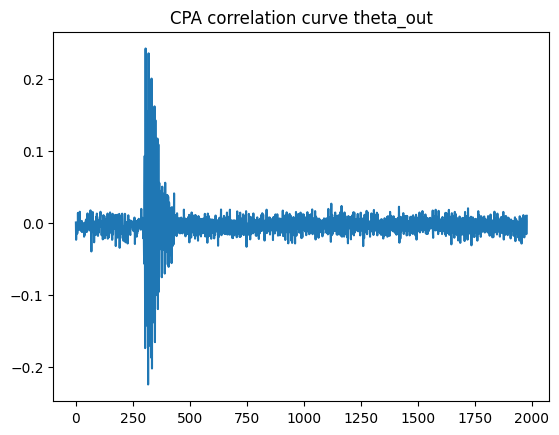

[theta_out] Hyperparameter Tuning...
[theta_out] Best hyperparameters found: {'num_blocks': 1, 'init_filters': 32, 'dense_units': 64, 'lr': 0.001, 'dropout': 0.3}
[theta_out] Tuned Model Training...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Attack Report for the target theta_out
              precision    recall  f1-score   support

         0.0       0.57      0.61      0.59      3114
         1.0       0.61      0.57      0.59      3286

    accuracy                           0.59      6400
   macro avg       0.59      0.59      0.59      6400
weighted avg       0.59      0.59      0.59      6400

Global bit accuracy on attack set: 58.96875
Best Trace: Trace 59 -> 45/64 bit
Worst Trace: Trace 87 -> 28/64 bit
----------------------------------------------------------------------------------------------------
ANALYSIS ON THE TARGET: rho_pi_out
[rho_pi_out] Percentage of bits 1: 51.34%
Best 50 Point of Interest:  [301 350 352 379 337 366 420 392 300 403 340 407 309 324 353 325 390 354
 377 

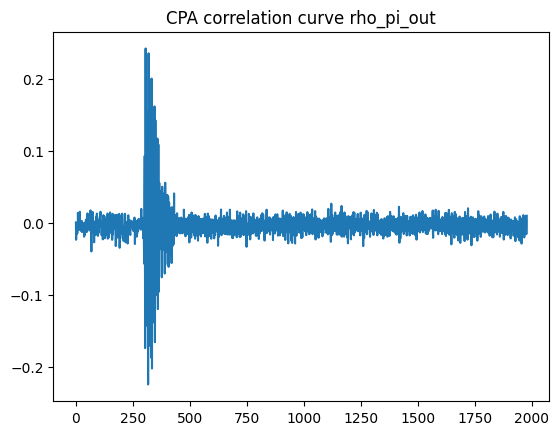

[rho_pi_out] Hyperparameter Tuning...
[rho_pi_out] Best hyperparameters found: {'num_blocks': 1, 'init_filters': 32, 'dense_units': 64, 'lr': 0.001, 'dropout': 0.3}
[rho_pi_out] Tuned Model Training...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Attack Report for the target rho_pi_out
              precision    recall  f1-score   support

         0.0       0.58      0.57      0.58      3114
         1.0       0.60      0.61      0.61      3286

    accuracy                           0.59      6400
   macro avg       0.59      0.59      0.59      6400
weighted avg       0.59      0.59      0.59      6400

Global bit accuracy on attack set: 59.3125
Best Trace: Trace 52 -> 45/64 bit
Worst Trace: Trace 24 -> 31/64 bit
----------------------------------------------------------------------------------------------------
ANALYSIS ON THE TARGET: chi_out
[chi_out] Percentage of bits 1: 25.38%
Best 50 Point of Interest:  [350 301 379 352 420 337 366 300 392 403 340 407 309 324 353 390 325 354
 377 310

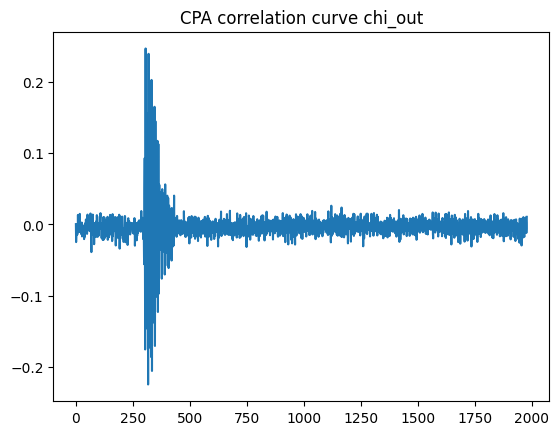

[chi_out] Hyperparameter Tuning...
[chi_out] Best hyperparameters found: {'num_blocks': 1, 'init_filters': 16, 'dense_units': 64, 'lr': 0.001, 'dropout': 0.4}
[chi_out] Tuned Model Training...
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000028E5A91A7A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Attac

In [21]:
sasca_payloads = {}

for target_name, target_data in targets.items():
    print("-"*100)
    print("ANALYSIS ON THE TARGET:", target_name)
    
    # 64-bit multi-label vectors for the lane target
    train_labels = np.zeros((len(traces), 64), dtype=np.float32)
    attack_labels = np.zeros((len(attack_traces), 64), dtype=np.float32)
    for i in range(64):
        train_labels[:, i] = (target_data["train"] >> i) & 1
        attack_labels[:, i] = (target_data["attack"] >> i) & 1
        
    # check if classess are balanced
    ones_ratio = np.mean(attack_labels)
    print(f"[{target_name}] Percentage of bits 1: {ones_ratio*100:.2f}%")
    
    # HW leakage function call for every target 
    if target_name == "theta_out":
        current_leakage = compute_hw_leakage(theta_tr)
    elif target_name == "rho_pi_out":
        current_leakage = compute_hw_leakage(rho_pi_tr)
    elif target_name == "chi_out":
        current_leakage = compute_hw_leakage(chi_tr)
    
    # CPA & POI Selection
    top_k_POI, corrs = select_pois(traces, current_leakage, num_pois=50)
    print("Best 50 Point of Interest: ", top_k_POI)
    print("Max Correlation: ", np.max(np.abs(corrs)))

    plt.plot(corrs)
    plt.title("CPA correlation curve " + target_name)
    plt.show()
    
    # pre-processing
    X_poi = traces[:, top_k_POI]
    X_train, X_test, y_train, y_test = train_test_split(X_poi, train_labels, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
    X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))
    
    X_tr, X_val, y_tr, y_val = train_test_split(X_train_cnn, y_train, test_size=0.2, random_state=42)
    
    # Hyperparameter Tuning
    print(f"[{target_name}] Hyperparameter Tuning...")
    best_hparams = tune_cnn_architecture(X_tr, y_tr, X_val, y_val)
    print(f"[{target_name}] Best hyperparameters found: {best_hparams}")
    
    # Model Training
    print(f"[{target_name}] Tuned Model Training...")
    final_model = build_and_train_best_model(X_train_cnn, y_train, best_hparams)
    
    # Profiling Attack
    attack_poi = attack_traces[:, top_k_POI]
    attack_poi = scaler.transform(attack_poi)
    attack_poi = attack_poi.reshape((attack_poi.shape[0], attack_poi.shape[1], 1))
    
    attack_probs = final_model.predict(attack_poi)
    attack_preds = (attack_probs > 0.5).astype(int)
    
    # Probs matrix for sasca
    sasca_payloads[target_name] = attack_probs
    
    # attack final report
    print("Attack Report for the target", target_name)
    print(classification_report(attack_labels.flatten(), attack_preds.flatten()))
    
    bit_accuracy = np.mean(attack_preds == attack_labels)
    print("Global bit accuracy on attack set:", bit_accuracy * 100)
    
    correct_per_trace = np.sum(attack_preds == attack_labels, axis=1)
    best_trace = np.argmax(correct_per_trace)
    worst_trace = np.argmin(correct_per_trace)
    print(f"Best Trace: Trace {best_trace} -> {correct_per_trace[best_trace]}/64 bit")
    print(f"Worst Trace: Trace {worst_trace} -> {correct_per_trace[worst_trace]}/64 bit")